In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Setelah mount drive, buat folder checkpoint dulu
import os
os.makedirs('/content/drive/Shareddrives/ML/checkpoints', exist_ok=True)

# Callbacks dengan checkpoint — SELALU pakai ini
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

def get_callbacks(model_name):
    return [
        EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.2, patience=3, verbose=1),
        ModelCheckpoint(
            f'/content/drive/Shareddrives/ML/checkpoints/{model_name}_best.keras',
            save_best_only=True,
            monitor='val_accuracy',
            verbose=1
        )
    ]

In [ ]:
!cp -r '/content/drive/Shareddrives/ML/PlantVillage' '/content/PlantVillage'
print("✅ Selesai copy!")

✅ Selesai copy!


In [ ]:
DATASET_PATH = '/content/PlantVillage/PlantVillage'  # lokal, bukan Drive (diperbaiki)

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS_CNN   = 20
EPOCHS_EFF   = 10
SEED         = 42

class_names  = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES  = len(class_names)

print(f"Jumlah kelas : {NUM_CLASSES}")
print(f"Daftar kelas : {class_names}")

Jumlah kelas : 15
Daftar kelas : ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


Total gambar : 20639

Distribusi:
             Count
count    15.000000
mean   1375.933333
std     744.654615
min     152.000000
25%     998.500000
50%    1404.000000
75%    1723.500000
max    3209.000000

Per kelas:
                                      Class  Count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3209
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
                        Tomato_Early_blight   1000
              Pepper__bell___Bacterial_spot    997
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                  

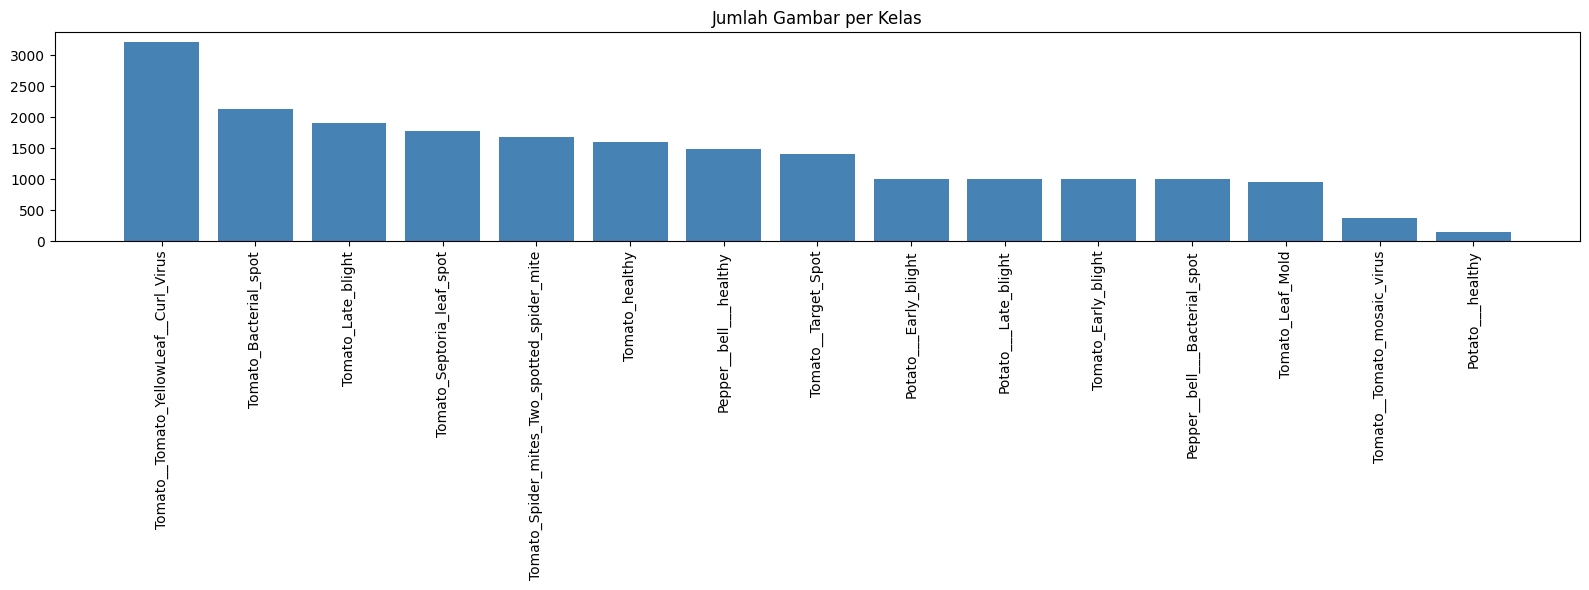

In [ ]:
class_counts = {}
for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False)

print(f"Total gambar : {df_counts['Count'].sum()}")
print(f"\nDistribusi:\n{df_counts.describe()}")
print(f"\nPer kelas:\n{df_counts.to_string(index=False)}")

plt.figure(figsize=(16, 6))
plt.bar(df_counts['Class'], df_counts['Count'], color='steelblue')
plt.xticks(rotation=90)
plt.title('Jumlah Gambar per Kelas')
plt.tight_layout()
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

print(f"Train : {train_gen.samples} gambar")
print(f"Val   : {val_gen.samples} gambar")

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Train : 16516 gambar
Val   : 4122 gambar


In [ ]:
# Generator khusus EfficientNet (tanpa rescale)
eff_train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

eff_val_datagen = ImageDataGenerator(
    validation_split=0.2
)

eff_train_gen = eff_train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

eff_val_gen = eff_val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

print(f"EfficientNet Train : {eff_train_gen.samples} gambar")
print(f"EfficientNet Val   : {eff_val_gen.samples} gambar")

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
EfficientNet Train : 16516 gambar
EfficientNet Val   : 4122 gambar


In [ ]:
def build_cnn(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Classifier head
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_cnn(NUM_CLASSES)
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,248,527 (84.87 MB)

 Trainable params: 22,248,527 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.4387 - loss: 1.8245
Epoch 1: val_accuracy improved from None to 0.75910, saving model to /content/drive/Shareddrives/ML/checkpoints/cnn_best.keras

Epoch 1: finished saving model to /content/drive/Shareddrives/ML/checkpoints/cnn_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 247s 461ms/step - accuracy: 0.6027 - loss: 1.2386 - val_accuracy: 0.7591 - val_loss: 0.7169 - learning_rate: 0.0010
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.7887 - loss: 0.6399
Epoch 2: val_accuracy did not improve from 0.75910
517/517 ━━━━━━━━━━━━━━━━━━━━ 231s 446ms/step - accuracy: 0.8029 - loss: 0.5916 - val_accuracy: 0.7162 - val_loss: 0.9569 - learning_rate: 0.0010
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8558 - loss: 0.4337
Epoch 3: val_accuracy improved from 0.75910 to 0.83261, saving model to /content/drive/Shareddrives/ML/checkpoints/cnn_best.keras

Epoch 3: finished saving model to /content/d

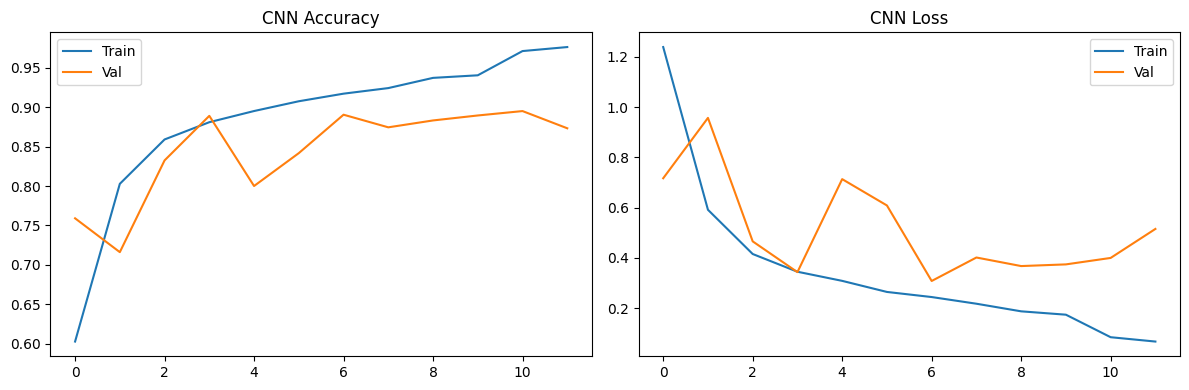

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]

history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_CNN,
    callbacks=get_callbacks('cnn')   # ← nama model
)

# Setelah selesai, save juga versi final
cnn_model.save('/content/drive/Shareddrives/ML/checkpoints/cnn_final.keras')

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Val')
plt.title('CNN Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train')
plt.plot(history_cnn.history['val_loss'], label='Val')
plt.title('CNN Loss'); plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_efficientnet(num_classes, input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(preprocess_input)(inputs)

    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    base_model.trainable = False

    out = layers.GlobalAveragePooling2D()(base_model.output)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(256, activation='relu')(out)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)

    model = models.Model(inputs=inputs, outputs=out)
    return model, base_model

effnet_model, effnet_base = build_efficientnet(NUM_CLASSES)
effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ lambda[0][0]      │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,381,362 (16.71 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]

# Phase 1: train head dulu, base frozen
history_eff1 = effnet_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=EPOCHS_EFF,
    callbacks=get_callbacks('effnet_phase1')
)
effnet_model.save('/content/drive/Shareddrives/ML/checkpoints/effnet_phase1_final.keras')

# Phase 2: fine-tuning, unfreeze 20 layer terakhir
effnet_base.trainable = True
for layer in effnet_base.layers[:-20]:
    layer.trainable = False

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff2 = effnet_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=10,
    callbacks=get_callbacks('effnet_phase2')
)
effnet_model.save('/content/drive/Shareddrives/ML/checkpoints/effnet_phase2_final.keras')

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.6438 - loss: 1.1201
Epoch 1: val_accuracy improved from None to 0.87846, saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase1_best.keras

Epoch 1: finished saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase1_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 290s 501ms/step - accuracy: 0.7630 - loss: 0.7384 - val_accuracy: 0.8785 - val_loss: 0.3529 - learning_rate: 0.0010
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8621 - loss: 0.4159
Epoch 2: val_accuracy improved from 0.87846 to 0.92698, saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase1_best.keras

Epoch 2: finished saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase1_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 223s 431ms/step - accuracy: 0.8656 - loss: 0.4001 - val_accuracy: 0.9270 - val_loss: 0.2378 - learning_rate: 0.0010
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/st

In [ ]:

# Output langsung setelah GlobalAveragePooling
feature_extractor = models.Model(
    inputs=effnet_model.input,
    outputs=effnet_model.layers[-4].output
)

# Generator tanpa rescale (konsisten dengan EfficientNet)
extract_datagen = ImageDataGenerator(validation_split=0.2)

train_ext = extract_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=False,  # penting!
    seed=SEED
)

val_ext = extract_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Mengekstrak fitur train...")
X_train_feat = feature_extractor.predict(train_ext, verbose=1)
y_train_feat = train_ext.classes

print("Mengekstrak fitur val...")
X_val_feat = feature_extractor.predict(val_ext, verbose=1)
y_val_feat = val_ext.classes

print(f"Shape train: {X_train_feat.shape}")  # harusnya (N, 1280)
print(f"Shape val  : {X_val_feat.shape}")

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Mengekstrak fitur train...
517/517 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step
Mengekstrak fitur val...
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step
Shape train: (16516, 1280)
Shape val  : (4122, 1280)


In [ ]:
# ===== Cell 12 — Train XGBoost =====

print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(
    X_train_feat, y_train_feat,
    eval_set=[(X_val_feat, y_val_feat)],
    verbose=50
)
print("XGBoost selesai!")

# Simpan
import joblib
joblib.dump(xgb_model, '/content/drive/Shareddrives/ML/checkpoints/xgb_model.pkl')

Training XGBoost...
[0]	validation_0-mlogloss:2.10382
[50]	validation_0-mlogloss:0.16710
[100]	validation_0-mlogloss:0.09017
[150]	validation_0-mlogloss:0.07660
[199]	validation_0-mlogloss:0.07201
XGBoost selesai!


['/content/drive/Shareddrives/ML/checkpoints/xgb_model.pkl']

129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step

Model    : CNN Sederhana
Accuracy : 0.0767
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.05      0.05      0.05       199
                     Pepper__bell___healthy       0.08      0.08      0.08       295
                      Potato___Early_blight       0.06      0.07      0.06       200
                       Potato___Late_blight       0.03      0.03      0.03       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.08      0.08      0.08       425
                        Tomato_Early_blight       0.03      0.04      0.04       200
                         Tomato_Late_blight       0.08      0.07      0.08       381
                           Tomato_Leaf_Mold       0.04      0.04      0.04       190
                  Tomato_Septoria_leaf_spot       0.08      0.0

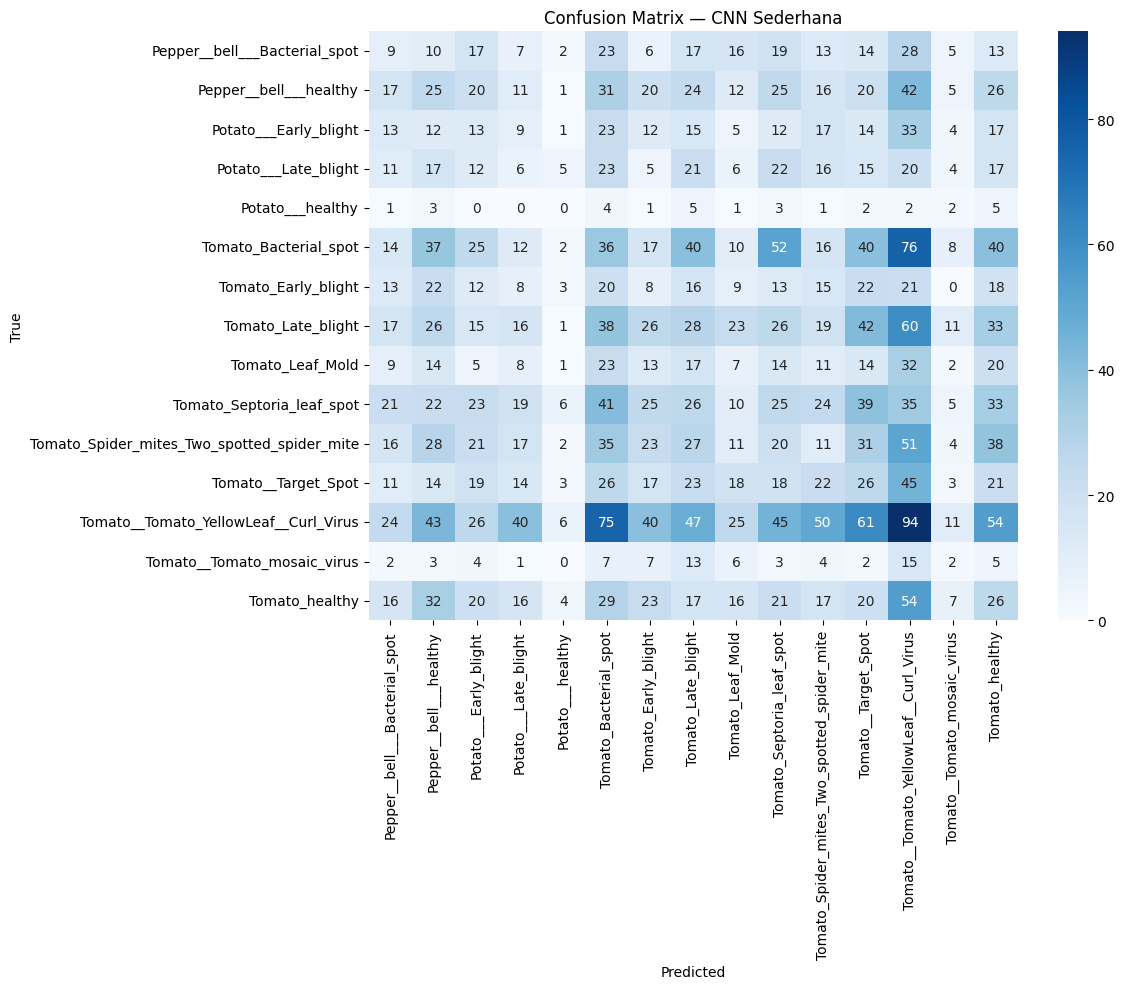

129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step

Model    : EfficientNetB0
Accuracy : 0.0859
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00       199
                     Pepper__bell___healthy       0.00      0.00      0.00       295
                      Potato___Early_blight       0.00      0.00      0.00       200
                       Potato___Late_blight       0.00      0.00      0.00       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.00      0.00      0.00       425
                        Tomato_Early_blight       0.00      0.00      0.00       200
                         Tomato_Late_blight       0.00      0.00      0.00       381
                           Tomato_Leaf_Mold       0.00      0.00      0.00       190
                  Tomato_Septoria_leaf_spot       0.09      1.

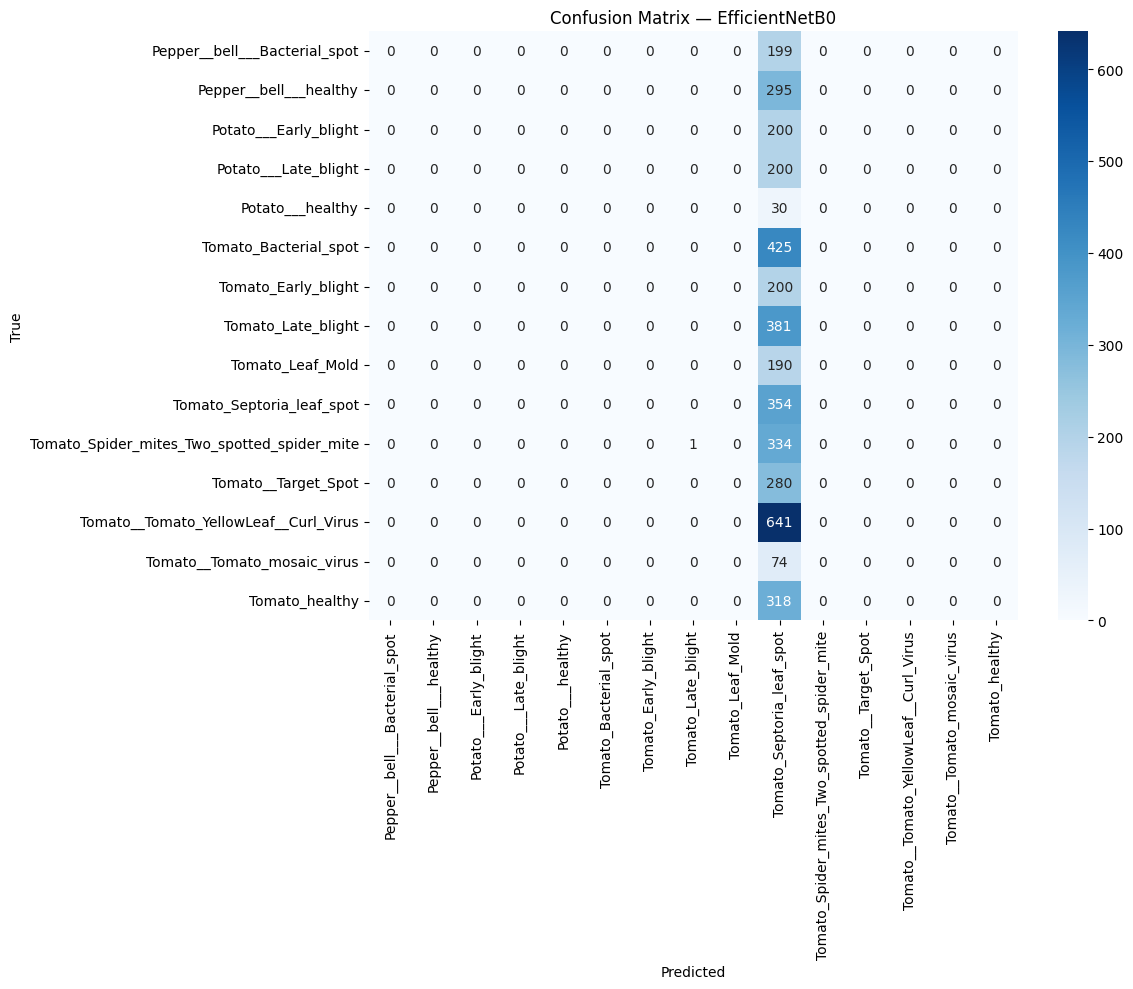


Model    : Hybrid EfficientNetB0-XGBoost
Accuracy : 0.9767
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.98      0.99       199
                     Pepper__bell___healthy       0.99      0.99      0.99       295
                      Potato___Early_blight       0.99      0.99      0.99       200
                       Potato___Late_blight       1.00      0.97      0.99       200
                           Potato___healthy       1.00      0.97      0.98        30
                      Tomato_Bacterial_spot       0.97      0.99      0.98       425
                        Tomato_Early_blight       0.93      0.90      0.92       200
                         Tomato_Late_blight       0.96      0.99      0.97       381
                           Tomato_Leaf_Mold       0.98      0.98      0.98       190
                  Tomato_Septoria_leaf_spot       0.99      0.96      0.97       354
Toma

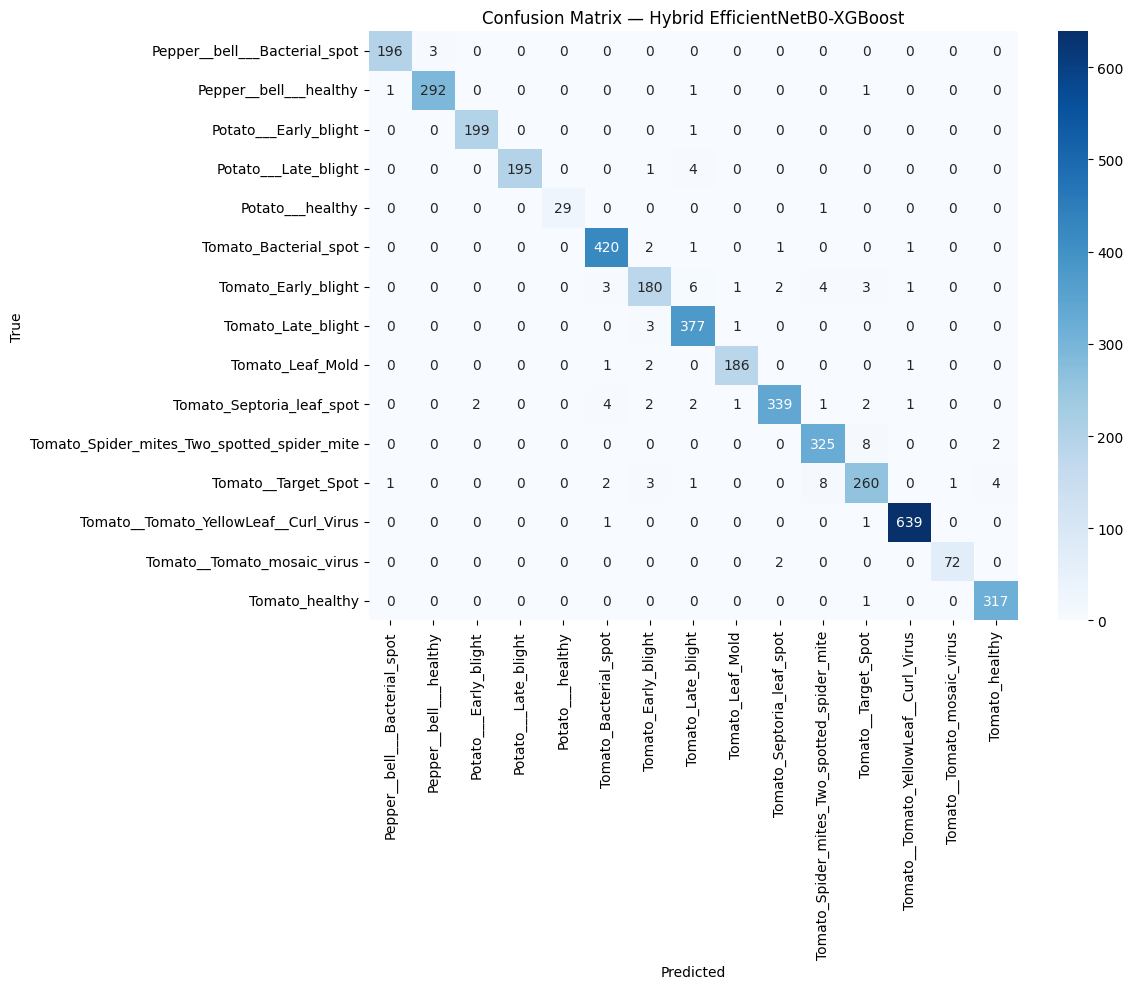

In [ ]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"Model    : {name}")
    print(f"Accuracy : {acc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names,
                                zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    return acc

# CNN
val_gen.reset()
y_pred_cnn = np.argmax(cnn_model.predict(val_gen, verbose=1), axis=1)
acc_cnn = evaluate_model("CNN Sederhana", val_gen.classes, y_pred_cnn)

# EfficientNetB0
val_gen.reset()
y_pred_eff = np.argmax(effnet_model.predict(val_gen, verbose=1), axis=1) # ini salah  nih harusnya eff_val _gen bukan val_gen
acc_eff = evaluate_model("EfficientNetB0", val_gen.classes, y_pred_eff)

# Hybrid
y_pred_hyb = xgb_model.predict(X_val_feat)
acc_hyb = evaluate_model("Hybrid EfficientNetB0-XGBoost", y_val_feat, y_pred_hyb)

                        Model  Accuracy
Hybrid EfficientNetB0-XGBoost  0.976710
               EfficientNetB0  0.085881
                CNN Sederhana  0.076662


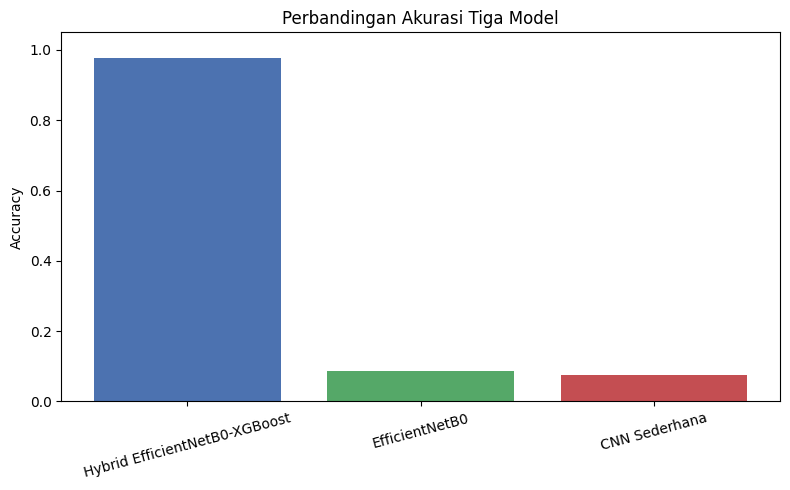

In [ ]:
results = pd.DataFrame({
    'Model'    : ['CNN Sederhana', 'EfficientNetB0', 'Hybrid EfficientNetB0-XGBoost'],
    'Accuracy' : [acc_cnn, acc_eff, acc_hyb]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))

plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
plt.bar(results['Model'], results['Accuracy'], color=colors)
plt.ylim(0.0, 1.05) # Mengubah batas sumbu y agar semua model terlihat
plt.title('Perbandingan Akurasi Tiga Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

PERBAIKANNN

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp -r '/content/drive/Shareddrives/ML/PlantVillage' '/content/PlantVillage'
print("✅ Dataset siap!")

✅ Dataset siap!


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import joblib

DATASET_PATH = '/content/PlantVillage'
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

class_names  = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES  = len(class_names)
print(f"Kelas: {NUM_CLASSES}")

Kelas: 15


In [5]:
CHECKPOINT_PATH = '/content/drive/Shareddrives/ML/checkpoints/'

# Import the preprocess_input function for EfficientNet
from tensorflow.keras.applications.efficientnet import preprocess_input

# Define custom_objects dictionary to handle the custom function during loading
custom_objects = {'preprocess_input': preprocess_input}

cnn_model    = tf.keras.models.load_model(CHECKPOINT_PATH + 'cnn_best.keras', custom_objects=custom_objects)
effnet_model = tf.keras.models.load_model(CHECKPOINT_PATH + 'effnet_phase2_final.keras', custom_objects=custom_objects)
xgb_model    = joblib.load(CHECKPOINT_PATH + 'xgb_model.pkl')

print("Semua model berhasil diload")

Semua model berhasil diload


di cnn sama effnet itu shuffle nya default bukan false

In [6]:
# CNN — rescale 1/255
eval_cnn_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_cnn_gen = eval_cnn_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# EfficientNet — tanpa rescale
eval_eff_datagen = ImageDataGenerator(validation_split=0.2)
eval_eff_gen = eval_eff_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print(f"Eval CNN    : {eval_cnn_gen.samples} gambar")
print(f"Eval EffNet : {eval_eff_gen.samples} gambar")

Found 4122 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Eval CNN    : 4122 gambar
Eval EffNet : 4122 gambar


In [7]:
feature_extractor = models.Model(
    inputs=effnet_model.input,
    outputs=effnet_model.layers[-4].output
)

extract_datagen = ImageDataGenerator(validation_split=0.2)
val_ext = extract_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

X_val_feat = feature_extractor.predict(val_ext, verbose=1)
y_val_feat = val_ext.classes
print(f"Shape: {X_val_feat.shape}")  # harusnya (4122, 1280)

Found 4122 images belonging to 15 classes.
129/129 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step
Shape: (4122, 1280)


In [8]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"Model    : {name}")
    print(f"Accuracy : {acc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names,
                                zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    return acc

129/129 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step
Model    : CNN Sederhana
Accuracy : 0.9384
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.94      0.96       199
                     Pepper__bell___healthy       0.95      0.98      0.96       295
                      Potato___Early_blight       0.88      1.00      0.94       200
                       Potato___Late_blight       0.84      0.96      0.90       200
                           Potato___healthy       0.68      0.93      0.79        30
                      Tomato_Bacterial_spot       0.93      0.99      0.96       425
                        Tomato_Early_blight       0.90      0.91      0.90       200
                         Tomato_Late_blight       0.97      0.87      0.92       381
                           Tomato_Leaf_Mold       0.98      0.97      0.97       190
                  Tomato_Septoria_leaf_spot       0.97      0.86

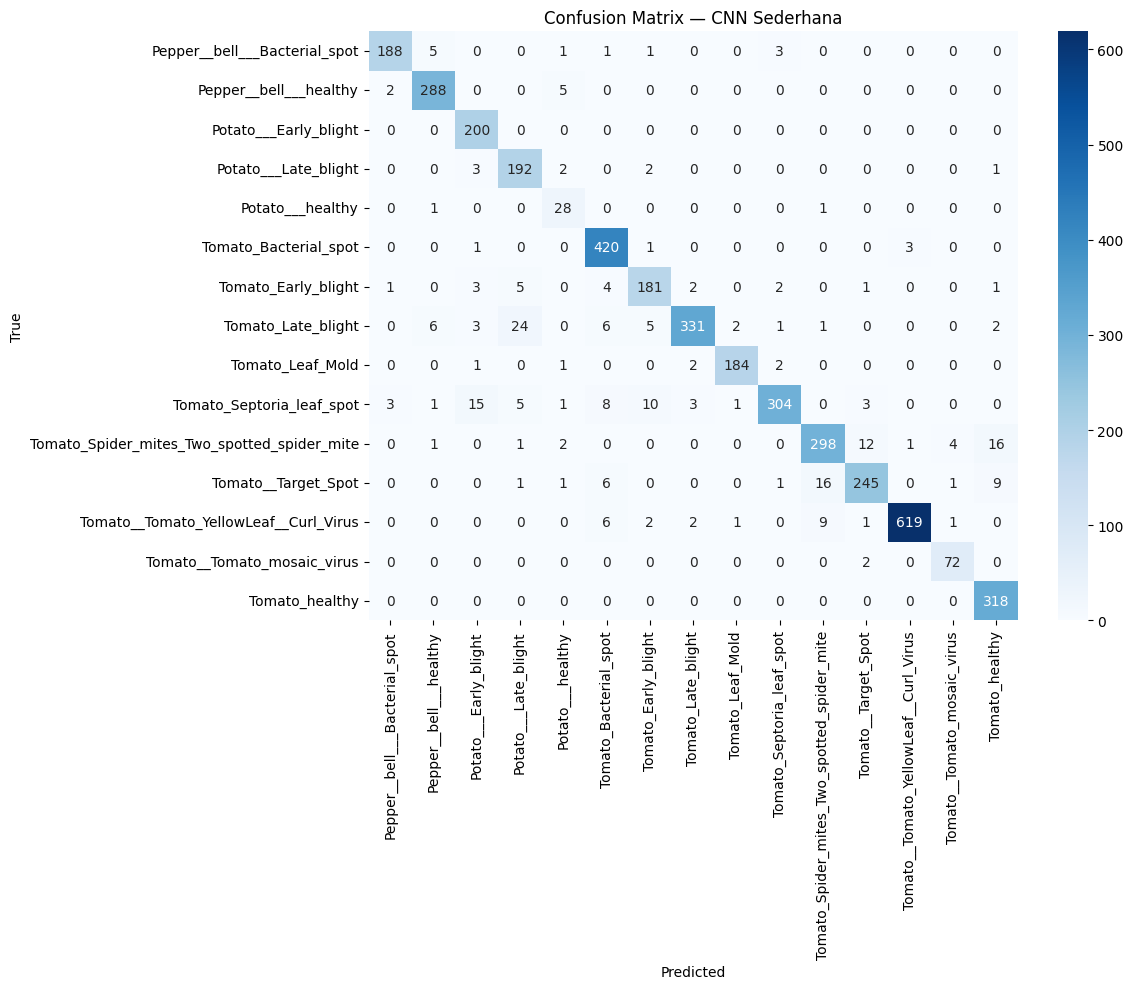

129/129 ━━━━━━━━━━━━━━━━━━━━ 2437s 19s/step
Model    : EfficientNetB0
Accuracy : 0.9850
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       199
                     Pepper__bell___healthy       1.00      1.00      1.00       295
                      Potato___Early_blight       1.00      1.00      1.00       200
                       Potato___Late_blight       1.00      0.98      0.99       200
                           Potato___healthy       1.00      1.00      1.00        30
                      Tomato_Bacterial_spot       1.00      0.99      0.99       425
                        Tomato_Early_blight       0.97      0.93      0.95       200
                         Tomato_Late_blight       0.98      0.99      0.98       381
                           Tomato_Leaf_Mold       0.98      1.00      0.99       190
                  Tomato_Septoria_leaf_spot       0.98      0

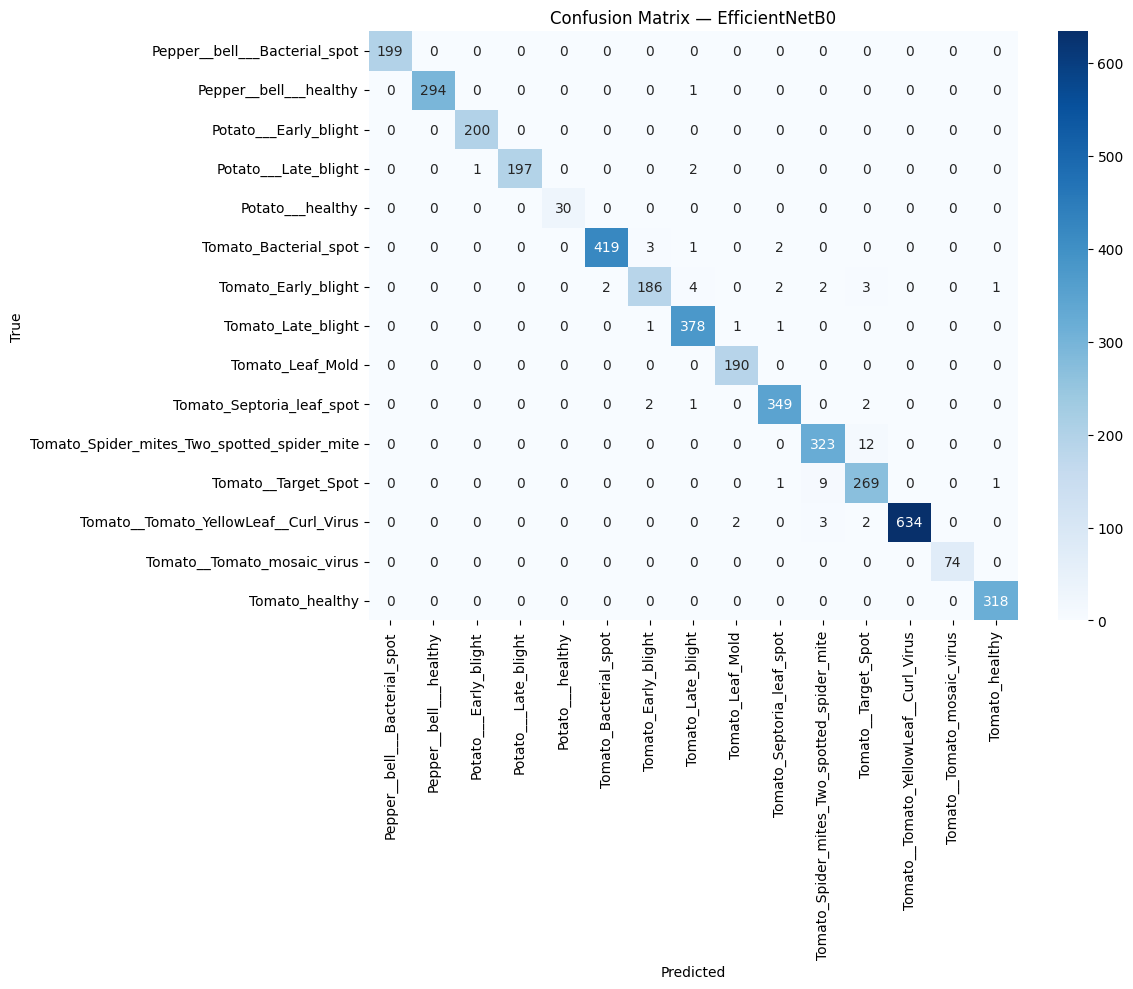

Model    : Hybrid EfficientNetB0-XGBoost
Accuracy : 0.9767
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.97      0.98       199
                     Pepper__bell___healthy       0.98      0.99      0.98       295
                      Potato___Early_blight       0.99      0.99      0.99       200
                       Potato___Late_blight       0.99      0.97      0.98       200
                           Potato___healthy       0.94      0.97      0.95        30
                      Tomato_Bacterial_spot       0.98      0.99      0.98       425
                        Tomato_Early_blight       0.97      0.91      0.94       200
                         Tomato_Late_blight       0.96      0.98      0.97       381
                           Tomato_Leaf_Mold       0.99      0.98      0.99       190
                  Tomato_Septoria_leaf_spot       0.97      0.97      0.97       354
Tomat

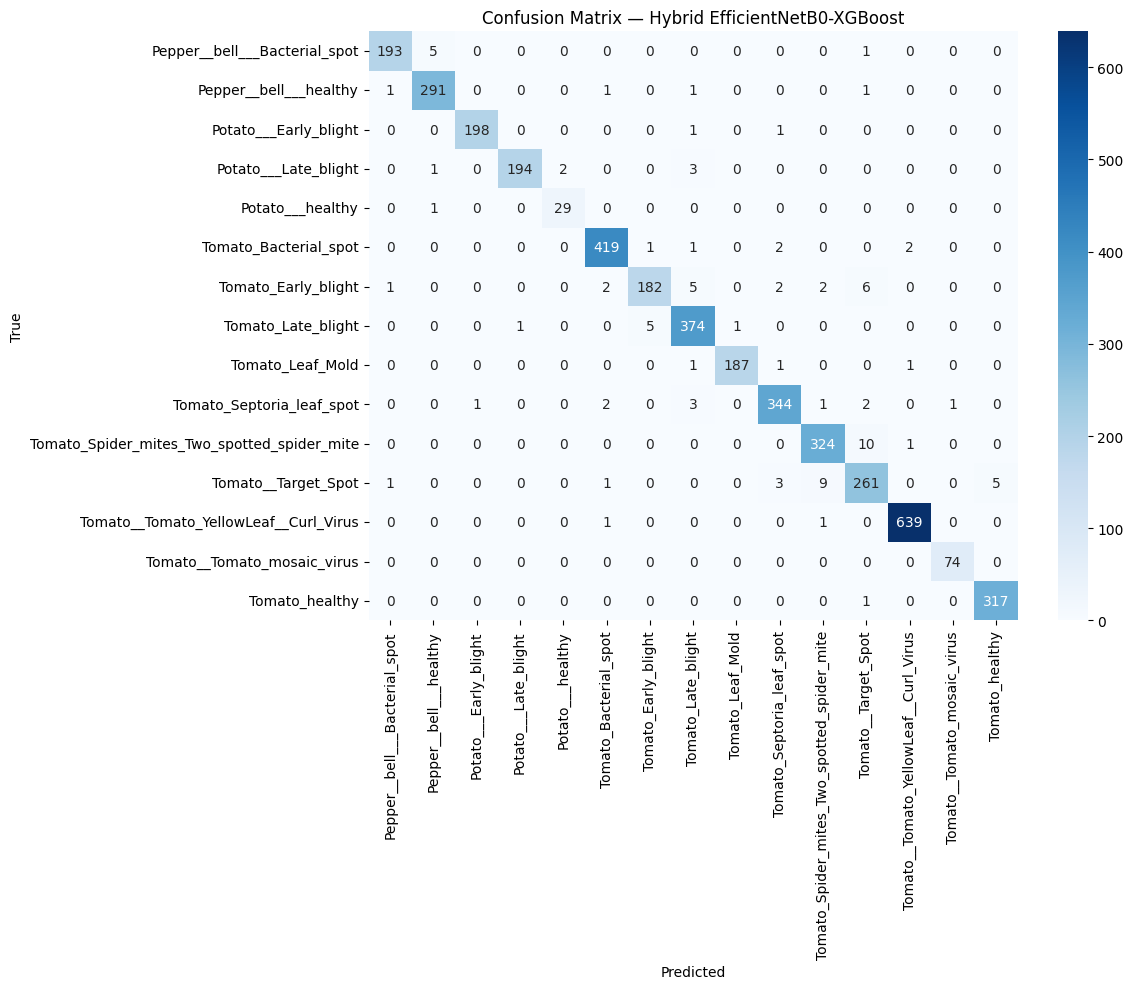

In [9]:
# CNN
y_pred_cnn = np.argmax(cnn_model.predict(eval_cnn_gen, verbose=1), axis=1)
acc_cnn = evaluate_model("CNN Sederhana", eval_cnn_gen.classes, y_pred_cnn)

# EfficientNetB0
y_pred_eff = np.argmax(effnet_model.predict(eval_eff_gen, verbose=1), axis=1)
acc_eff = evaluate_model("EfficientNetB0", eval_eff_gen.classes, y_pred_eff)

# Hybrid XGBoost
y_pred_hyb = xgb_model.predict(X_val_feat)
acc_hyb = evaluate_model("Hybrid EfficientNetB0-XGBoost", y_val_feat, y_pred_hyb)

                        Model  Accuracy
               EfficientNetB0  0.984959
Hybrid EfficientNetB0-XGBoost  0.976710
                CNN Sederhana  0.938379


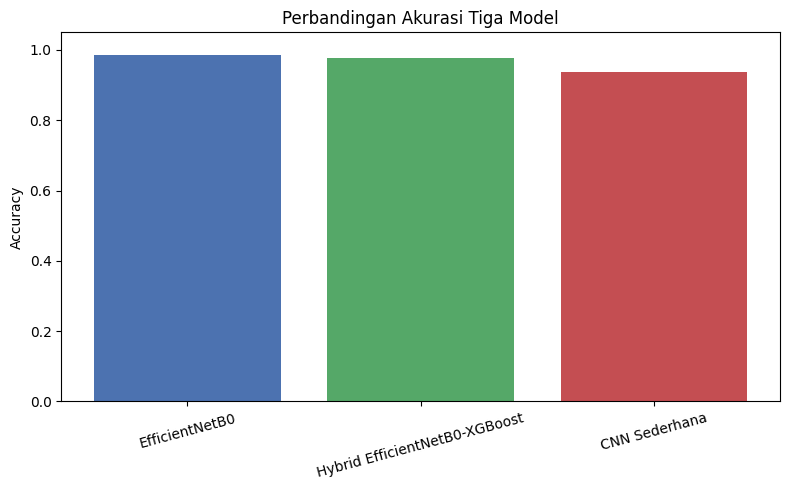

In [10]:
import pandas as pd

results = pd.DataFrame({
    'Model'    : ['CNN Sederhana', 'EfficientNetB0', 'Hybrid EfficientNetB0-XGBoost'],
    'Accuracy' : [acc_cnn, acc_eff, acc_hyb]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))

plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
plt.bar(results['Model'], results['Accuracy'], color=colors)
plt.ylim(0.0, 1.05)
plt.title('Perbandingan Akurasi Tiga Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()